# Middleware

Middleware provides a way to more tightly control what happens inside the agent. Middleware is useful for the following:
- Tracking agent behavior with logging, analytics, and debugging.
- Transforming prompts, tool selection, and output formatting.
- Adding retries, fallbacks, and early termination logic.
- Applying rate limits, guardrails, and PII detection.

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_openai import ChatOpenAI
openai_api_key = os.getenv("OPENAI_API_KEY")
openai_base_url = os.getenv("OPENAI_BASE_URL")
model = ChatOpenAI(
    model="gpt-4.1",
    api_key = openai_api_key,
    base_url = openai_base_url
)
model

ChatOpenAI(profile={'max_input_tokens': 1047576, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x0000016F8A283CB0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x0000016F8A780980>, root_client=<openai.OpenAI object at 0x0000016F8A280830>, root_async_client=<openai.AsyncOpenAI object at 0x0000016F8A7806E0>, model_name='gpt-4.1', model_kwargs={}, openai_api_key=SecretStr('**********'), openai_api_base='https://yibuapi.com/v1')

## Summarization MiddleWare
Automatically summarize conversation history when approaching token limits, preserving recent messages while compressing older context. Summarization is useful for the following:
- Long-running conversations that exceed context windows.
- Multi-turn dialogues with extensive history.
- Applications where preserving full conversation context matters.

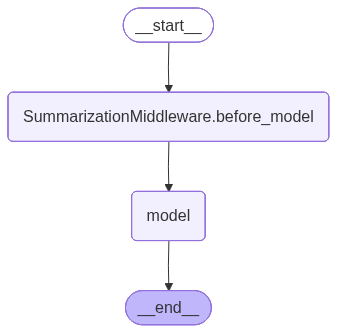

In [2]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage

agent = create_agent(
    model = "gpt-4o-mini",
    checkpointer = InMemorySaver(),
    middleware = [
        SummarizationMiddleware(
            model = "gpt-4o-mini",
            trigger = ("messages", 10),
            keep = ("messages", 4))
    ]
)
agent

In [3]:
### Run with thread id
config = {
    "configurable": {"thread_id": "awu"}
}

In [4]:
# Alternative test data
questions = [
    "What is 2+2?",
    "What is 10*5?",
    "What is 100/4?",
    "What is 15-7?",
    "What is 3*3?",
    "What is 4*4?",
]

for q in questions:
    response = agent.invoke({"messages": [HumanMessage(content=q)]}, config=config)
    print(f"Response: {response}")
    print(f"Message: {len(response['messages'])}")

Response: {'messages': [HumanMessage(content='What is 2+2?', additional_kwargs={}, response_metadata={}, id='4431b37c-e9a5-4735-9f42-a500a4772f10'), AIMessage(content='2 + 2 equals 4.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 14, 'total_tokens': 23, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini', 'system_fingerprint': 'fp_eb37e061ec', 'id': 'chatcmpl-DKJZBYrDGG146p1AMsdChdAkjC4xs', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019cfacb-41d5-7e51-9aca-33c7655b2564-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 14, 'output_tokens': 9, 'total_tokens': 23, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}
Messa

## Token Size

In [5]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

@tool
def search_hotels(city: str) -> str:
    """Search hotels - returns long response to use more tokens."""
    return f"""Hotels in {city}:
    1. Grand Hotel - 5 star, $350/night, spa, pool, gym
    2. City Inn - 4 star, $180/night, business center
    3. Budget Stay - 3 star, $75/night, free wifi"""


agent = create_agent(
    model = "gpt-4",
    tools = [search_hotels],
    checkpointer = InMemorySaver(),
    middleware = [
        SummarizationMiddleware(
            model = "gpt-4o-mini",
            trigger = ("tokens", 500),
            keep = ("tokens", 200)
        )
])

config = {"configurable": {"thread_id": "awu-1"}}

def count_token(messages):
    total_chars = sum(len(str(m.content)) for m in messages)
    return total_chars // 4

In [6]:
cities = ["Paris", "London", "Tokyo", "New York", "Dubai", "Singapore"]

for city in cities:
    response = agent.invoke(
        {"messages": HumanMessage(content=f"Search for hotels in {city}")},
        config=config
    )

    tokens = count_token(response["messages"])
    print(f"{city}: ~{tokens} tokens, {len(response['messages'])} messages")
    print(f"{(response['messages'])}")

Paris: ~127 tokens, 4 messages
[HumanMessage(content='Search for hotels in Paris', additional_kwargs={}, response_metadata={}, id='8b2be1c0-82af-4388-b0a5-c842e0a6368b'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 54, 'total_tokens': 70, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4', 'system_fingerprint': 'fp_af7f7349a4', 'id': 'chatcmpl-DKJa1jIO5WqmLKipvm1jTfW1bNyxE', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019cfacc-1106-7550-a8cb-12115a06f0dc-0', tool_calls=[{'name': 'search_hotels', 'args': {'city': 'Paris'}, 'id': 'call_18ajkerL7w2jA5e8GRL1yWxh', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 54, 'output_t

## Fraction

In [7]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

@tool
def search_hotels(city: str) -> str:
    """Search hotels."""
    return f"Hotels in {city}: Grand Hotel $350, City Inn $180, Budget Stay $75"

# LOW fraction for testing!
agent = create_agent(
    model="gpt-4o-mini",
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="gpt-4o-mini",
            trigger=("fraction", 0.005),  # 0.5% = ~640 tokens
            keep=("fraction", 0.002),     # 0.2% = ~256 tokens
        ),
    ],
)

config = {"configurable": {"thread_id": "test-1"}}

# Token counter
def count_tokens(messages):
    return sum(len(str(m.content)) for m in messages) // 4

# Test
cities = ["Paris", "London", "Tokyo", "New York", "Dubai", "Singapore"]

for city in cities:
    response = agent.invoke(
        {"messages": [HumanMessage(content=f"Hotels in {city}")]},
        config=config
    )
    tokens = count_tokens(response["messages"])
    fraction = tokens / 128000  # gpt-4o-mini context
    print(f"{city}: ~{tokens} tokens ({fraction:.4%}), {len(response['messages'])} msgs")
    print(response['messages'])

Paris: ~68 tokens (0.0531%), 4 msgs
[HumanMessage(content='Hotels in Paris', additional_kwargs={}, response_metadata={}, id='cb500484-c53b-4c8f-8e9a-1ae3baeb7e15'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 44, 'total_tokens': 60, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini', 'system_fingerprint': 'fp_eb37e061ec', 'id': 'chatcmpl-DKJcFOclPQCJ9TLyqRomKA9tx8sl4', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019cface-2d3c-7e10-933c-6e4a7de48e42-0', tool_calls=[{'name': 'search_hotels', 'args': {'city': 'Paris'}, 'id': 'call_kTqCwVEIBZ6N00rG3O5jIpUO', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 44, 'output_t

# Human In the Loop MiddleWare

Pause agent execution for human approval, editing, or rejection of tool calls before they execute. Human-in-the-loop is useful for the following:
- High-stakes operations requiring human approval (e.g. database writes, financial transactions).
- Compliance workflows where human oversight is mandatory.
- Long-running conversations where human feedback guides the agent.

In [8]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}' and body '{body}'"

In [9]:
agent = create_agent(
    model = "gpt-4",
    tools = [read_email_tool, send_email_tool],
    checkpointer = InMemorySaver(),
    middleware = [
        HumanInTheLoopMiddleware(
            interrupt_on = {
                "send_email_tool": {
                    "allowed_decisions": ["approve", "reject", "edit"]
                },
                "read_email_tool": False
            }
        )
    ]
)

In [10]:
config = {"configurable": {"thread_id": "awu-2"}}

result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config
)

In [11]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='ff1983f9-90d6-4892-9165-b1adb14bfa68'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 97, 'total_tokens': 126, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4', 'system_fingerprint': 'fp_af7f7349a4', 'id': 'chatcmpl-DKJdDgFfPzIRg8h0Vg7T6dwt2TvzB', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019cfacf-163b-7753-b6ee-f032e3a2ebca-0', tool_calls=[{'name': 'send_email_tool', 'args': {'recipient': 'john@test.com', 'subject': 'Hello', 'body': 'How are you?'}, 'id': 'call_SwXxhBIcmswQRcHoPxJztvHp', '

In [14]:
# step 2: Approve
from langgraph.types import Command
if "__interrupt__" in result:
    print("⏸️ Paused! Approving...")
    result = agent.invoke(
        Command(
            resume = {
                "decisions": [
                    {"type": "approve"}
                ]
            }
        ),
        config = config
    )
    print(f"✅ Result: {result['messages'][-1].content}")

⏸️ Paused! Approving...
✅ Result: The email has been sent to john@test.com with the subject "Hello."


In [15]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='835dd03c-c0e0-4915-9143-3cdd6e4134e0'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 97, 'total_tokens': 126, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o', 'system_fingerprint': 'fp_af7f7349a4', 'id': 'chatcmpl-DKJdHcyR3rW93qjItNla9iBBsJIHH', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019cfacf-27df-7090-97a4-16571cf07904-0', tool_calls=[{'name': 'send_email_tool', 'args': {'recipient': 'john@test.com', 'subject': 'Hello', 'body': 'How are you?'}, 'id': 'call_wQtthSiUOfNQx1Y4he7cBZlh', 

## Reject

In [16]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver


def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

agent = create_agent(
    model="gpt-4o",
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"],
                },
                "read_email_tool": False,
            }
        ),
    ],
)

config = {"configurable": {"thread_id": "test-reject"}}
# Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config)

In [17]:
# Step 2: Reject
if "__interrupt__" in result:
    print("⏸️ Paused! Approving...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "reject"}
                ]
            }
        ),
        config=config
    )
    
    print(f"✅ Result: {result['messages'][-1].content}")

⏸️ Paused! Approving...
✅ Result: It seems you rejected sending the email. Is there something you'd like to modify or clarify?


In [18]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='731b4b79-6800-42c1-8fd0-42acb2123d84'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 97, 'total_tokens': 126, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}, 'input_tokens': 0, 'input_tokens_details': None, 'output_tokens': 0}, 'model_provider': 'openai', 'model_name': 'gpt-4o', 'system_fingerprint': 'fp_e9b9b028d7', 'id': 'chatcmpl-DKJe7IhNQldCQVP0iPT9E9uh1DTRd', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019cfacf-e4de-7450-981d-bfa31d44d96e-0', tool_calls=[{'name': 'send_email_tool', 'args': {'recipient': 'john@test.com', 'subject': 'Hello', 'body': 'How are you?'

# Edit

In [22]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver


def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

agent = create_agent(
    model="gpt-4o",
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"],
                },
                "read_email_tool": False,
            }
        ),
    ],
)

config = {"configurable": {"thread_id": "test-edit"}}
# Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config)

In [23]:
if "__interrupt__" in result:
    print("⏸️ Paused! Approving...")
    result = agent.invoke(
        Command(
            resume = {
                "decisions": [
                    {
                        "type": "edit",
                        "edited_action":{
                            "name": "send_email_tool",
                            "args": {
                                "recipient": "jane@test.com",
                                "subject": "Updated Subject",
                                "body": "Updated Body"
                            }
                        }
                    }
                ]
            }
        ),
        config = config
    )
    print(f"✅ Result: {result['messages'][-1].content}")

⏸️ Paused! Approving...
✅ Result: 


In [21]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='f01a8cf6-92c1-4639-a8cd-cfe6dd5369e2'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 97, 'total_tokens': 126, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}, 'input_tokens': 0, 'input_tokens_details': None, 'output_tokens': 0}, 'model_provider': 'openai', 'model_name': 'gpt-4o', 'system_fingerprint': 'fp_e9b9b028d7', 'id': 'chatcmpl-DKJeNR6FZpjSKOqNPgxV2iKT7TAOj', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019cfad0-2bbd-7180-ac41-7c5ca73aff89-0', tool_calls=[{'type': 'tool_call', 'name': 'send_email_tool', 'args': {'recipient': 'jane@test.com', 'subject': 'Updated S